# RL Examples for Lecture 8

In [ ]:
# Course utilities (do not modify this cell)

from pathlib import Path
import sys

# repo_root/16_06_Class/notebooks → repo_root/16_06_Class
repo_root = Path.cwd().parents[0]
sys.path.insert(0, str(repo_root))

import courseutils.basic_material as bm
import courseutils.control_materials as cm

bm.setup_environment()
cm.setup_environment()

import numpy as np
import matplotlib.pyplot as plt
colors = bm.get_colors()

from scipy.optimize import fsolve


In [3]:
colors = bm.get_colors()

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

import control as ct
import control.matlab as cmat

import warnings
warnings.filterwarnings(
    "ignore",
    message="divide by zero encountered in divide"
)
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in divide"
)

## Challenging case to sketch - which do you get? (8-8)
### Helps to know if there are break-in/out points (left one)

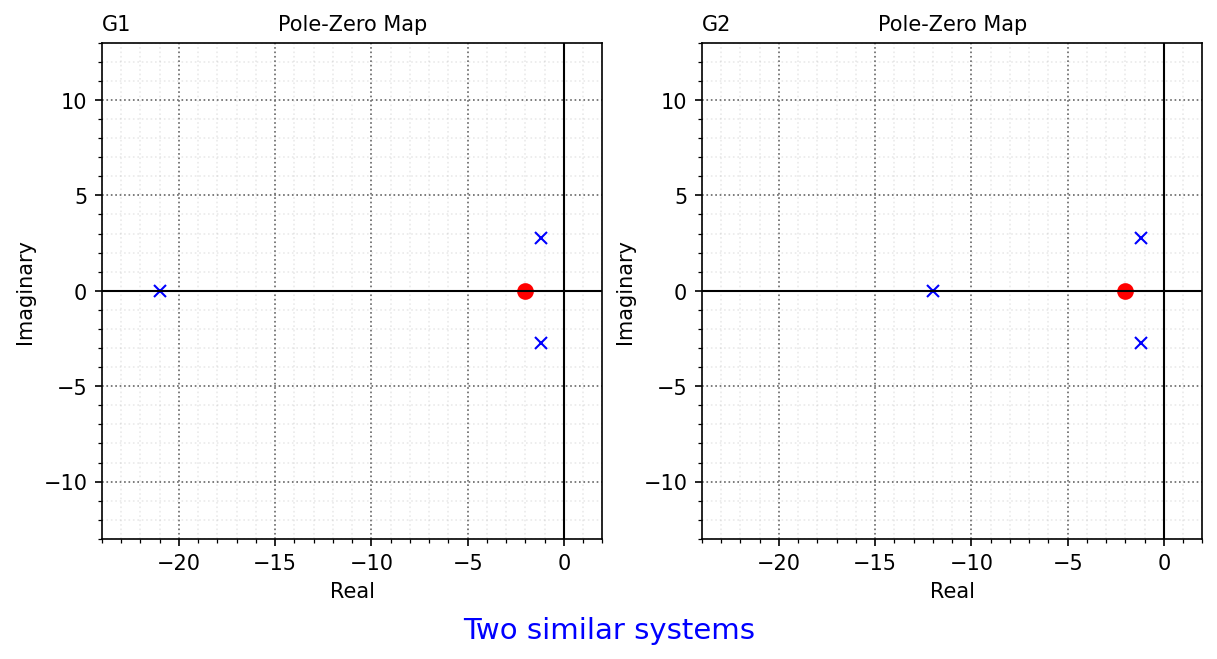

In [4]:
# form two similar systems
z1=2;p1=21
G1 = ct.tf((1,z1), np.convolve((1, 2*3*.4, 9),(1, p1)))
z2=2;p2=12
G2 = ct.tf((1,z2), np.convolve((1, 2*3*.4, 9),(1, p2)))
fig, ax = plt.subplots(1,2,figsize=(8, 4),dpi=150,constrained_layout = True)
cm.new_pzmap(G1, ax=ax[0])
ax[0].set_title('G1',loc='left')
cm.new_pzmap(G2, ax=ax[1])
ax[1].set_title('G2',loc='left')
cm.caption("Two similar systems",fig)
for kk in range(2):
    ax[kk].set_xlim([-24, 2]);ax[kk].set_ylim([-13,13])
    bm.nicegrid(ax[kk])

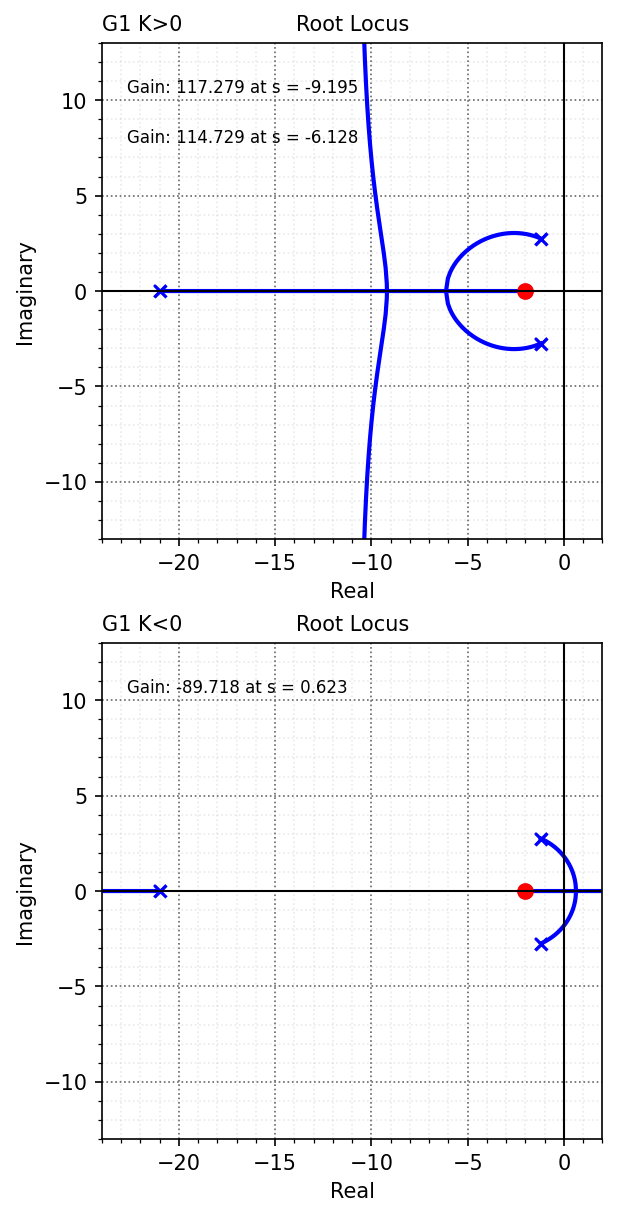

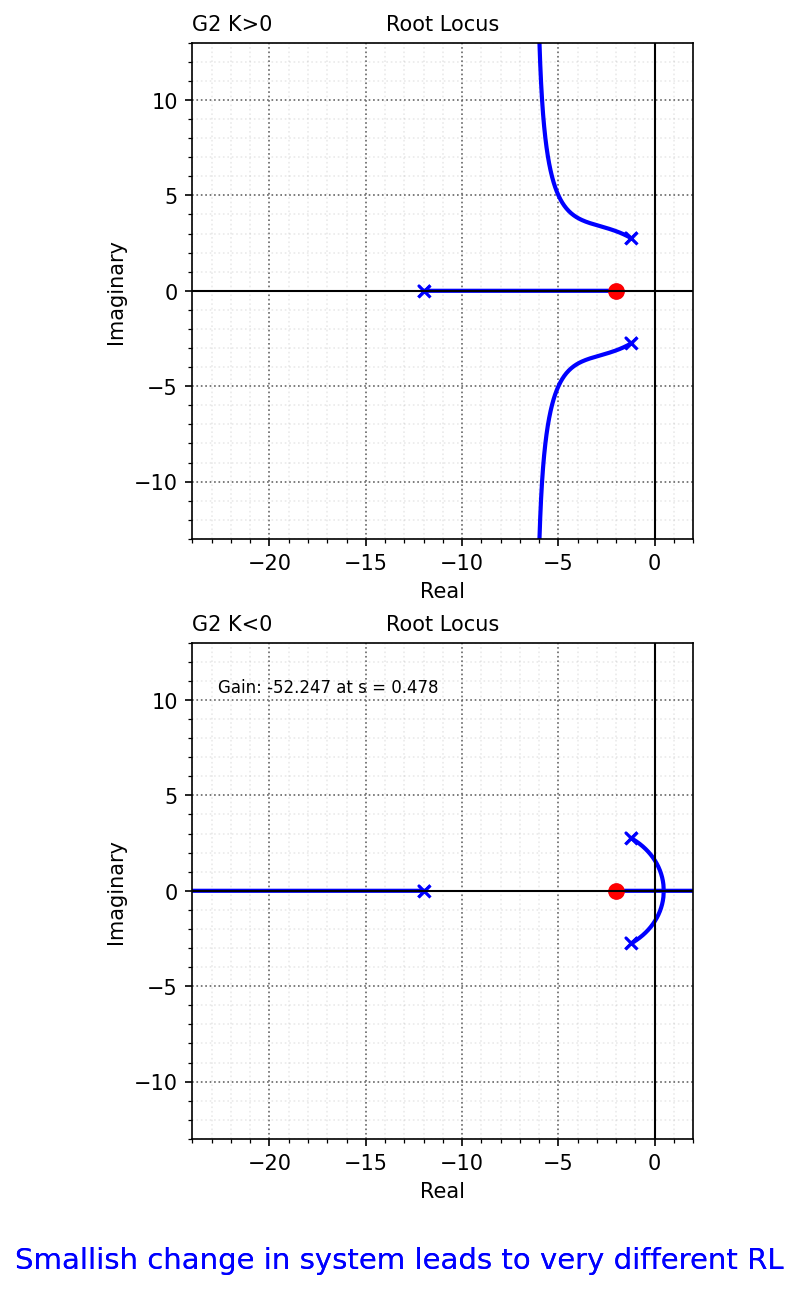

In [5]:
fig, ax = plt.subplots(2,1,figsize=(4,8),dpi=150,constrained_layout = True)
klist, break_info0 = cm.Root_Locus_gains(G1, verbose=True)
rl =  ct.rlocus(G1, gains=klist,  color='b',ax=ax[0])
ax[0].set_title('G1 K>0',loc='left')
cm.new_pzmap(G1, ax=ax[0], title="Root Locus")

klist, break_info1 = cm.Root_Locus_gains(G1, standard_locus=False, verbose=True)
rl =  ct.rlocus(G1, gains= klist,  color='b',ax=ax[1])
ax[1].set_title('G1 K<0',loc='left')
cm.new_pzmap(G1, ax=ax[1], title="Root Locus")

dim = 13
offset = 11
for kk in range(2):
    ax[kk].set_xlabel('Real')
    ax[kk].set_ylabel('Imaginary')
    ax[kk].set_xlim([-dim-offset, dim-offset]);
    ax[kk].set_ylim([-dim,dim])
    bm.nicegrid(ax[kk])

cm.add_break_info(ax[0],break_info0, dim=dim)
cm.add_break_info(ax[1],break_info1, dim=dim)

plt.savefig("./figs/Ex10_8a.pdf", dpi=600)
plt.show()

fig, ax = plt.subplots(2,1,figsize=(4,8),dpi=150,constrained_layout = True)
klist, break_info0 = cm.Root_Locus_gains(G2, verbose=True)
rl =  ct.rlocus(G2, gains=klist,  color='b',ax=ax[0])
ax[0].set_title('G2 K>0',loc='left')
cm.caption("Smallish change in system leads to very different RL",fig)
cm.new_pzmap(G2, ax=ax[0], title="Root Locus")

klist, break_info1 = cm.Root_Locus_gains(G2, standard_locus=False, verbose=True)
rl =  ct.rlocus(G2, gains= klist,  color='b',ax=ax[1])
ax[1].set_title('G2 K<0',loc='left')
cm.caption("Smallish change in system leads to very different RL",fig)
cm.new_pzmap(G2, ax=ax[1], title="Root Locus")

dim = 13
offset = 11
for kk in range(2):
    ax[kk].set_xlabel('Real')
    ax[kk].set_ylabel('Imaginary')
    ax[kk].set_xlim([-dim-offset, dim-offset]);
    ax[kk].set_ylim([-dim,dim])
    bm.nicegrid(ax[kk])

cm.add_break_info(ax[0],break_info0, dim=dim)
cm.add_break_info(ax[1],break_info1, dim=dim)
        
plt.savefig("./figs/Ex10_8b.pdf", dpi=600)
plt.show()

## Challenging case to sketch - which do you get? (8-10)
### Helps to know if there are break-in/out points (right one)

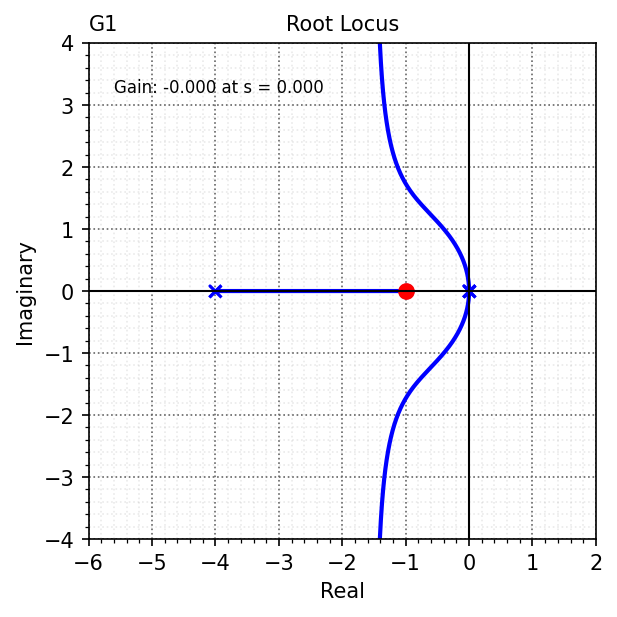

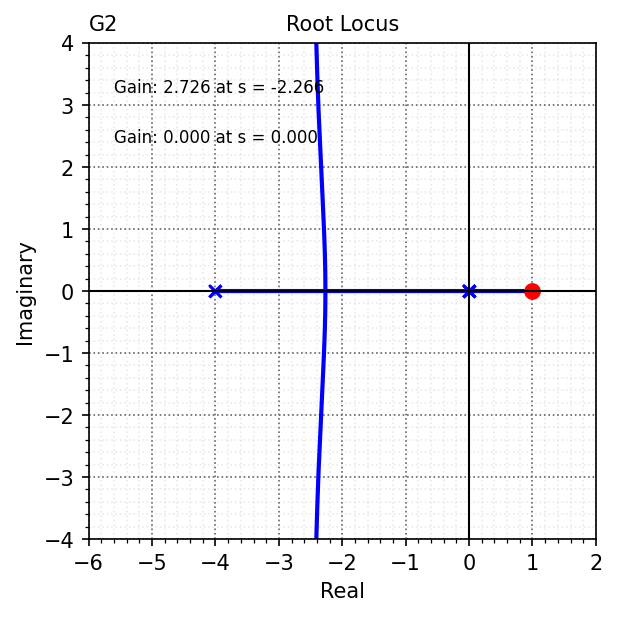

In [6]:
G1 = ct.tf((1,1), np.convolve((1, 0, 0),(1, 4)))
G2 = ct.tf((1,-1), np.convolve((1, 0, 0),(1, 4)))

fig0, ax0 = plt.subplots(1,figsize=(4, 4),dpi=150,constrained_layout = True)
klist, break_info0 = cm.Root_Locus_gains(G1, verbose=True)
rl =  ct.rlocus(G1, gains=klist,  color='b',ax=ax0)
ax0.set_title('G1',loc='left')
cm.new_pzmap(G1, ax=ax0, title="Root Locus")

fig1, ax1 = plt.subplots(1,figsize=(4, 4),dpi=150,constrained_layout = True)
klist, break_info1 = cm.Root_Locus_gains(G2, verbose=True)
rl =  ct.rlocus(G2, gains=klist,  color='b',ax=ax1)
ax1.set_title('G2',loc='left')
cm.new_pzmap(G2, ax=ax1, title="Root Locus")
for ax in [ax0,ax1]:
    ax.set_xlabel('Real')
    ax.set_ylabel('Imaginary')
    dim = 4
    ax.set_xlim([-dim-2, dim-2]);ax.set_ylim([-dim,dim])
    bm.nicegrid(ax)

cm.add_break_info(ax0,break_info0, dim=dim)
cm.add_break_info(ax1,break_info1, dim=dim)
        
fig0.savefig("./figs/Ex10_10a.pdf", dpi=600)
fig1.savefig("./figs/Ex10_10b.pdf", dpi=600)
plt.show()

# Break-in/Break-out Examples on 8-13

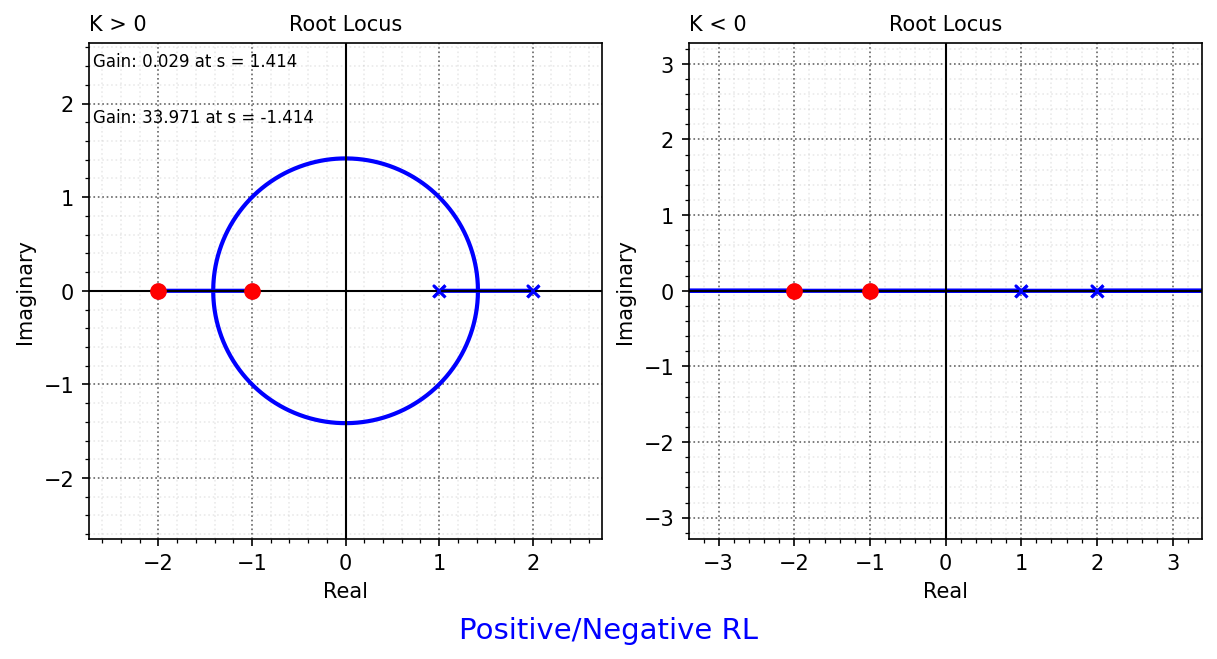

In [7]:
G = ct.tf(np.convolve((1, 2),(1, 1)), np.convolve((1, -2),(1, -1)))

fig, ax = plt.subplots(1,2,figsize=(8, 4),dpi=150,constrained_layout = True)
klist, break_info0 = cm.Root_Locus_gains(G, verbose=True)
rl =  ct.rlocus(G, gains=klist,  color='b',ax=ax[0])
ax[0].set_title('K > 0',loc='left')

klist, break_info1 = cm.Root_Locus_gains(G, verbose=True, standard_locus=False)
rl =  ct.rlocus(G, gains=klist,  color='b',ax=ax[1])
ax[1].set_title('K < 0',loc='left')
cm.caption("Positive/Negative RL",fig)

infos = [break_info0, break_info1]
dim = 3
for kk in range(2):
    ax[kk].axis('equal')
    ax[kk].set_xlim([-dim, dim])
    ax[kk].set_ylim([-dim, dim])
    bm.nicegrid(ax[kk])
    ax[kk].set_xlabel('Real')
    ax[kk].set_ylabel('Imaginary')
    cm.new_pzmap(G, ax=ax[kk], title="Root Locus")
    cm.add_break_info(ax[kk],infos[kk], dim=dim)

plt.savefig("./figs/Ex10_13a.pdf", dpi=600)
plt.show()


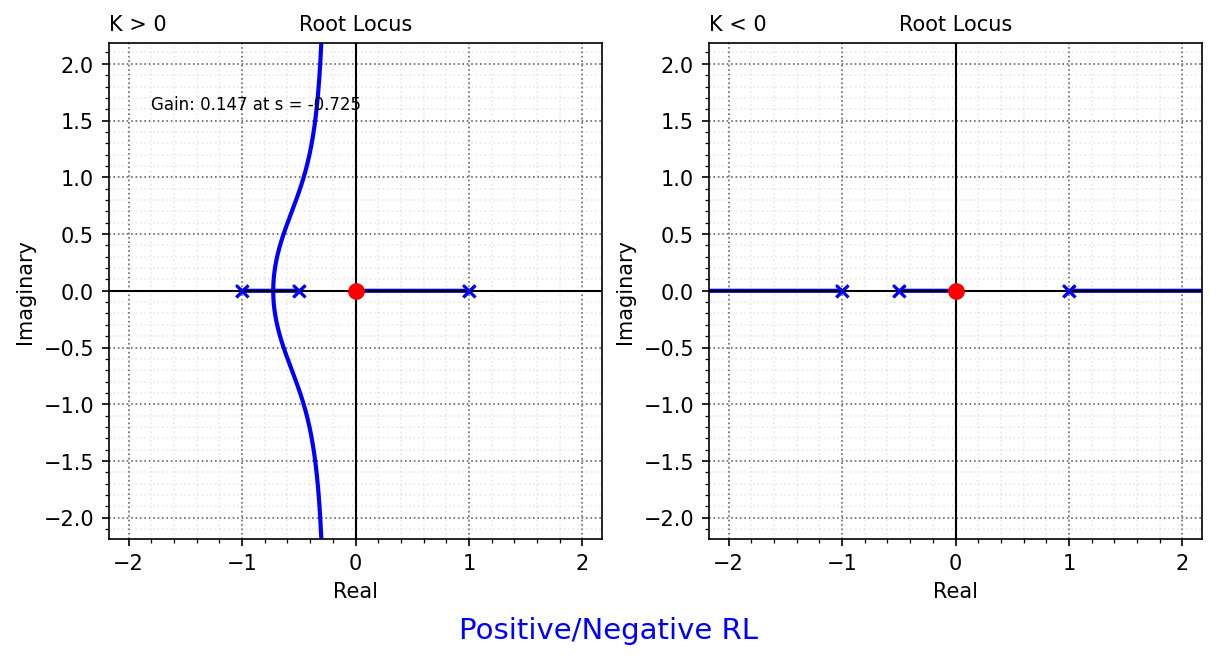

In [8]:
G = ct.tf(np.convolve((1, 0),(0, 1)), np.convolve((1, 0.5),(1, 0, -1)))

fig, ax = plt.subplots(1,2,figsize=(8, 4),dpi=150,constrained_layout = True)
klist, break_info0 = cm.Root_Locus_gains(G, verbose=True)
rl =  ct.rlocus(G, gains=klist,  color='b',ax=ax[0])
ax[0].set_title('K > 0',loc='left')

klist, break_info1 = cm.Root_Locus_gains(G, verbose=True, standard_locus=False)
rl =  ct.rlocus(G, gains=klist,  color='b',ax=ax[1])
ax[1].set_title('K < 0',loc='left')
cm.caption("Positive/Negative RL",fig)

dim = 2
infos = [break_info0, break_info1]
for kk in range(2):
    ax[kk].axis('equal')
    ax[kk].set_xlabel('Real')
    ax[kk].set_ylabel('Imaginary')
    ax[kk].set_xlim([-dim, dim])
    ax[kk].set_ylim([-dim, dim])
    bm.nicegrid(ax[kk])
    cm.new_pzmap(G, ax=ax[kk], title="Root Locus")
    cm.add_break_info(ax[kk],infos[kk], dim=dim)
       
plt.savefig("./figs/Ex10_13b.pdf", dpi=600)
plt.show()


## Simple RL with delay


Found break-in/out at K = 118.966
At possible locations s = 48.983

Found break-in/out at K =  3.034
At possible locations s = -8.983

Found break-in/out at K = 25.649
At possible locations s = 10.325

Found break-in/out at K =  0.351
At possible locations s = -2.325

Found break-in/out at K = 13.928
At possible locations s =  5.464

Found break-in/out at K =  0.072
At possible locations s = -1.464


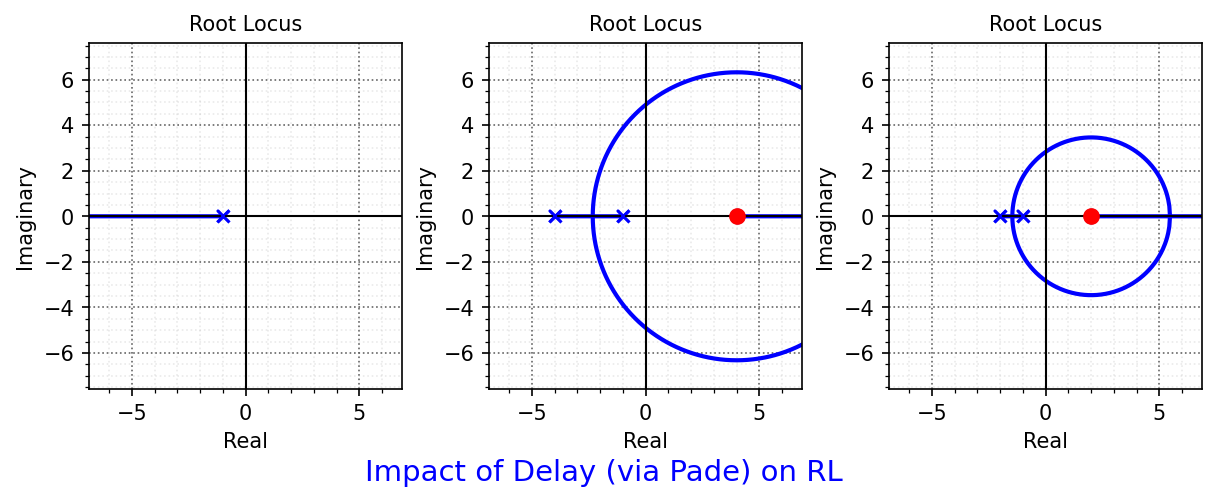

In [9]:
G = ct.tf((1), (1, 1))

fig, ax = plt.subplots(1,3, figsize=(8, 3),dpi=150,constrained_layout = True)

for kk,Td in enumerate(np.array([0.1,.5,1])):
    num, den = ct.pade(Td, 1)
    Gp = ct.tf(num,den)
    L = G*Gp
    klist = cm.Root_Locus_gains(L)
    rl =  ct.rlocus(G*Gp, gains=klist,  ax=ax[kk], color='b')
    ax[kk].axis('equal')
    ax[kk].set_xlim([-6, 6]);
    ax[kk].set_ylim([-6, 6])
    bm.nicegrid(ax[kk])
    ax[kk].set_title('Pade Td={0:2.2f}s'.format(Td))
    ax[kk].set_xlabel('Real')
    ax[kk].set_ylabel('Imaginary')
    cm.new_pzmap(L, ax=ax[kk], title="Root Locus")
cm.caption("Impact of Delay (via Pade) on RL ",fig)
plt.savefig("./figs/Ex10_16.pdf", dpi=600)
plt.show()

## RL Versus Parameter of Interest 

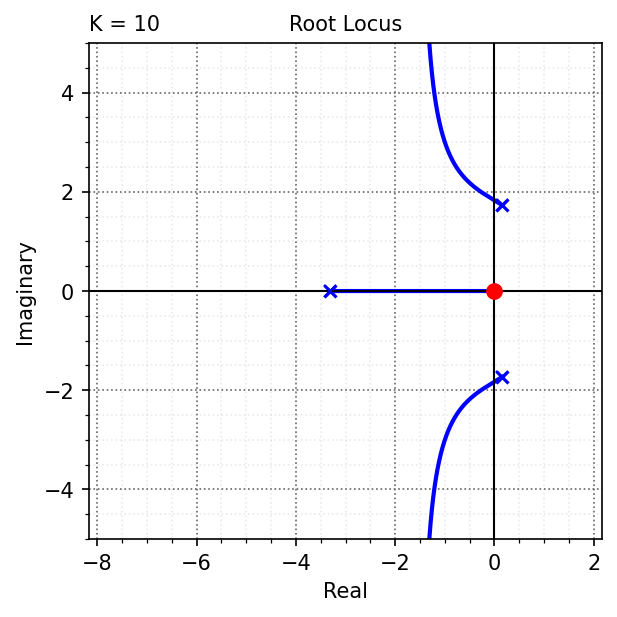

In [10]:
K = 10
G = ct.tf((K, 0), (1,3,2,K))
klist = cm.Root_Locus_gains(G)
fig, ax = plt.subplots(1,figsize=(4, 4),dpi=150,constrained_layout = True)
rl =  ct.rlocus(G, gains=klist,  color='b',ax=ax)
bm.nicegrid(ax)
ax.set_title('K = {:1d}'.format(K),loc='left')
ax.axis('equal')
ax.set_xlim([-8, 2]);ax.set_ylim([-5,5])
ax.set_xlabel('Real')
ax.set_ylabel('Imaginary')
cm.new_pzmap(G, ax=ax, title="Root Locus")
plt.savefig("./figs/RL_10_17.pdf", dpi=600)
plt.show()

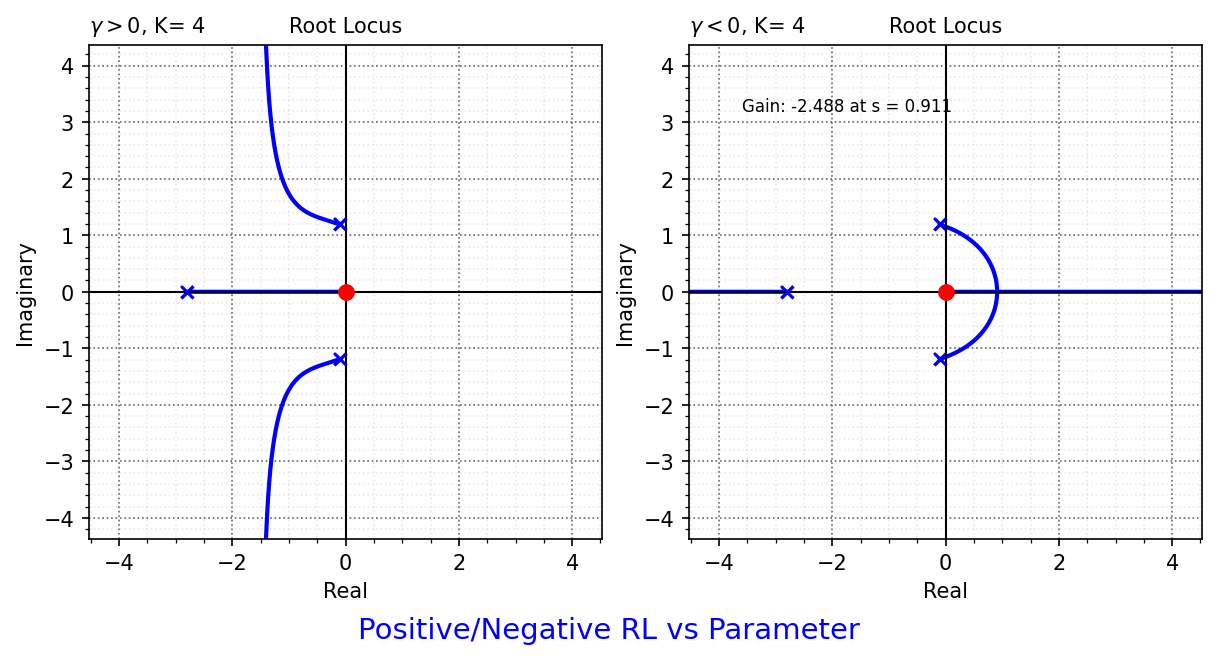

In [11]:
K = 4
G = ct.tf(np.convolve((K, 0),(0, 1)), np.convolve((1,3,2,K),(0, 1)))

fig, ax = plt.subplots(1,2,figsize=(8, 4),dpi=150,constrained_layout = True)

klist, break_info0 = cm.Root_Locus_gains(G, verbose=True)
rl =  ct.rlocus(G, gains=klist,  color='b',ax=ax[0])
bm.nicegrid(ax[0])
ax[0].set_title(rf"$\gamma > 0$, K={K:2d}",loc='left')
cm.new_pzmap(G, ax=ax[0], title="Root Locus")

klist, break_info1 = cm.Root_Locus_gains(G, standard_locus=False, verbose=True) 
rl =  ct.rlocus(G, gains=klist,  color='b',ax=ax[1])
bm.nicegrid(ax[1])
ax[1].set_title(rf"$\gamma < 0$, K={K:2d}",loc='left')
cm.new_pzmap(G, ax=ax[1], title="Root Locus")
cm.caption("Positive/Negative RL vs Parameter",fig)
for kk in range(2):
    ax[kk].axis('equal')
    ax[kk].set_xlabel('Real')
    ax[kk].set_ylabel('Imaginary')
    dim = 4
    ax[0].set_xlim([-dim, dim])
    ax[0].set_ylim([-dim, dim])
    ax[1].set_xlim([-dim, dim])
    ax[1].set_ylim([-dim, dim])

cm.add_break_info(ax[0],break_info0, dim=dim)
cm.add_break_info(ax[1],break_info1, dim=dim)
        
plt.savefig("./figs/RL_10_17a.pdf", dpi=600)
plt.show()

## Example 10-18

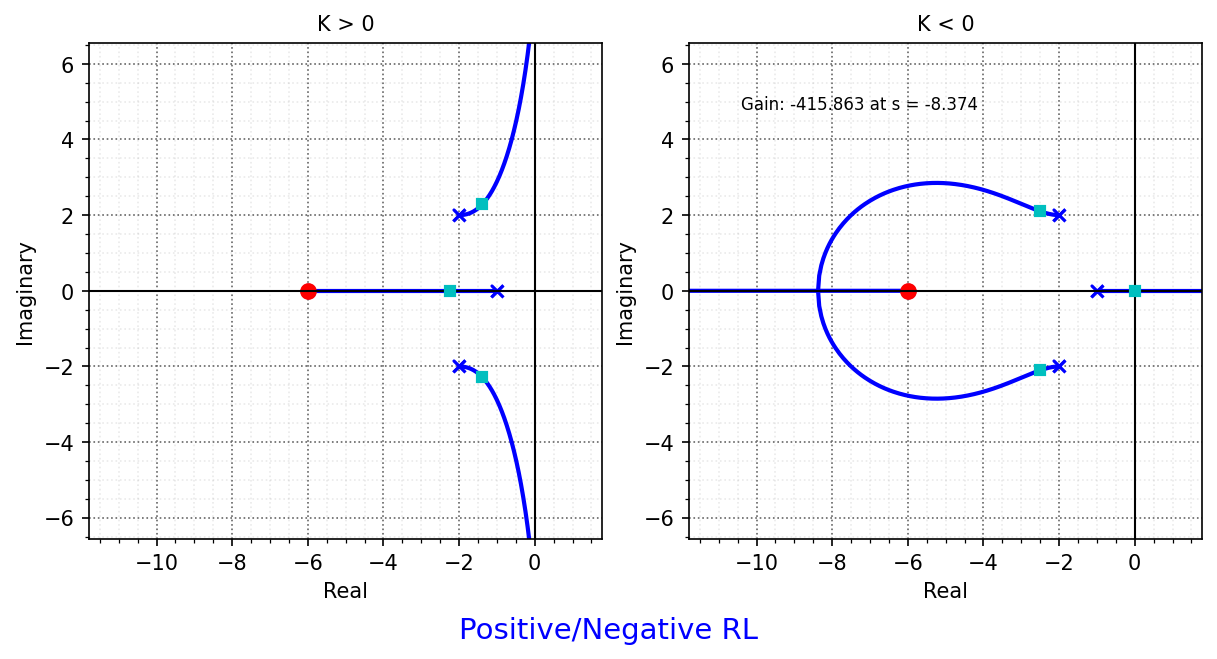

In [12]:
G = ct.tf((1, 6), np.convolve((1,4,8),(1, 1)))/3

K = ct.tf((4),(0, 1))
Gcl = ct.feedback(K,G)
scl0 = np.roots(Gcl.den[0][0])

fig, ax = plt.subplots(1,2,figsize=(8, 4),dpi=150,constrained_layout = True)
klist, break_info0 = cm.Root_Locus_gains(G,Krange=np.logspace(-4,4,1000), verbose=True)
rl =  ct.rlocus(G, gains=klist,  color='b',ax=ax[0])
a0_title = "K > 0"

K = ct.tf((-4),(0, 1))
Gcl = ct.feedback(K,G)
scl1 = np.roots(Gcl.den[0][0])
klist, break_info1 = cm.Root_Locus_gains(G, Krange = -np.logspace(-4,4,1000), verbose=True, standard_locus=False)
rl =  ct.rlocus(G, gains=klist,  color='b',ax=ax[1])
a1_title = "K < 0"

titles = [a0_title, a1_title]
cm.caption("Positive/Negative RL",fig)

scl = [scl0, scl1]
info = [break_info0, break_info1]
dim = 6
offset = 5
for kk in range(2):
    ax[kk].axis('equal')
    ax[kk].set_xlabel('Real')
    ax[kk].set_ylabel('Imaginary')
    cm.new_pzmap(G, ax=ax[kk], title=titles[kk])
    bm.nicegrid(ax[kk])
    ax[kk].set_xlim([-dim-offset, dim-offset])
    ax[kk].set_ylim([-dim, dim])
    cm.add_break_info(ax[kk],info[kk], dim=dim)
    ax[kk].plot(scl[kk].real,scl[kk].imag,'cs',ms=5)
    ax[kk].plot(scl[kk].real,-scl[kk].imag,'cs',ms=5)

plt.savefig("./figs/Ex10_18.pdf", dpi=600)
plt.show()